In [ ]:
!pip install faker pandas --quiet
print("Done")

Done


Config


In [ ]:
import os, random, uuid
from datetime import datetime, timedelta
import pandas as pd
from faker import Faker

fake = Faker("en_IN")
random.seed(42)

NUM_USERS    = 10_000
NUM_PRODUCTS =  5_000
NUM_ORDERS   = 100_000   # change to 5_000 for a quick test
START_DATE   = "2024-01-01"
END_DATE     = "2024-12-31"
OUTPUT_DIR   = "/content/generated_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

INDIAN_CITIES       = ["Mumbai","Delhi","Bangalore","Hyderabad","Chennai","Kolkata","Pune","Ahmedabad","Jaipur","Surat","Lucknow","Kanpur","Nagpur","Indore","Bhopal","Patna","Vadodara","Ludhiana","Agra","Nashik"]
PRODUCT_CATEGORIES  = ["Electronics","Fashion","Home & Kitchen","Books","Sports & Fitness","Beauty & Personal Care","Toys & Games","Grocery","Automotive","Office Supplies"]
PAYMENT_METHODS     = ["UPI","Credit Card","Debit Card","Net Banking","EMI","Cash on Delivery"]
PAYMENT_GATEWAYS    = ["Razorpay","PayU","CCAvenue","Stripe","Paytm"]
ORDER_STATUSES      = ["placed","confirmed","shipped","delivered","returned","cancelled"]

def random_date(start, end):
    s = datetime.strptime(start, "%Y-%m-%d")
    e = datetime.strptime(end,   "%Y-%m-%d")
    return (s + timedelta(days=random.randint(0, (e-s).days))).strftime("%Y-%m-%d %H:%M:%S")

print("Config ready")

Config ready


Generate Users


In [ ]:
users = []
for _ in range(NUM_USERS):
    d = random_date(START_DATE, END_DATE)
    users.append({"user_id": str(uuid.uuid4()), "name": fake.name(), "email": fake.email(),
                  "phone": fake.phone_number(), "city": random.choice(INDIAN_CITIES),
                  "state": fake.state(), "pincode": fake.postcode(),
                  "tier": random.choices(["bronze","silver","gold","platinum"], weights=[50,30,15,5])[0],
                  "signup_date": d, "is_active": random.choices([True,False], weights=[90,10])[0], "created_at": d})
users_df = pd.DataFrame(users)
users_df.to_csv(f"{OUTPUT_DIR}/users.csv", index=False)
print(f"users.csv — {len(users_df):,} rows")
users_df.head(3)

users.csv — 10,000 rows


,user_id,name,email,phone,city,state,pincode,tier,signup_date,is_active,created_at
0,95886029-242d-4621-9fdf-66d110cd8326,Chatura Mani,karnikrohan@example.net,9932372824,Hyderabad,Gujarat,140120,bronze,2024-11-23 00:00:00,True,2024-11-23 00:00:00
1,9ad9c6e6-78ff-44fd-8fd7-68732537aea7,Chakrika Kapur,mishraudant@example.org,08038450202,Chennai,Nagaland,010554,silver,2024-04-24 00:00:00,True,2024-04-24 00:00:00
2,2b976753-0648-465b-b5bc-d7165a995cee,Mohini Varghese,elijah43@example.org,+913226196631,Bangalore,Chhattisgarh,282351,silver,2024-10-06 00:00:00,True,2024-10-06 00:00:00


Generate Products

In [ ]:
products = []
for _ in range(NUM_PRODUCTS):
    cat = random.choice(PRODUCT_CATEGORIES)
    mrp = round(random.uniform(100, 50000), 2)
    disc = random.choice([0,5,10,15,20,25,30,40,50])
    products.append({"product_id": str(uuid.uuid4()), "product_name": f"{fake.word().capitalize()} {cat}",
                     "category": cat, "brand": fake.company(), "mrp": mrp,
                     "selling_price": round(mrp*(1-disc/100), 2), "discount_percentage": disc,
                     "rating": round(random.uniform(2.5, 5.0), 1), "rating_count": random.randint(10, 100000),
                     "is_available": random.choices([True,False], weights=[85,15])[0],
                     "created_at": random_date(START_DATE, END_DATE)})
products_df = pd.DataFrame(products)
products_df.to_csv(f"{OUTPUT_DIR}/products.csv", index=False)
print(f"products.csv — {len(products_df):,} rows")
products_df.head(3)

products.csv — 5,000 rows


,product_id,product_name,category,brand,mrp,selling_price,discount_percentage,rating,rating_count,is_available,created_at
0,fedc33ad-ac3e-48d2-b213-aa33cce1d413,In Office Supplies,Office Supplies,Arora PLC,381.32,285.99,25,3.2,55808,False,2024-11-30 00:00:00
1,92521e33-1e8e-4d63-928f-f9304fd0acd7,Dolore Automotive,Automotive,Pingle-Samra,24808.20,21086.97,15,4.3,6573,True,2024-09-21 00:00:00
2,e917d58a-024f-4fb4-a001-8445f22a0170,Cupiditate Automotive,Automotive,Seth-Sundaram,21494.88,20420.14,5,2.6,21090,True,2024-02-18 00:00:00


Generate Orders + Order Items

In [ ]:
orders, items, order_totals = [], [], {}

for _ in range(NUM_ORDERS):
    d = random_date(START_DATE, END_DATE)
    oid = str(uuid.uuid4())
    uid = random.choice(users_df["user_id"].tolist())
    status = random.choices(ORDER_STATUSES, weights=[5,10,15,55,8,7])[0]
    fee = random.choice([0,0,0,40,49,99])
    orders.append({"order_id": oid, "user_id": uid, "order_date": d, "status": status,
                   "shipping_city": random.choice(INDIAN_CITIES), "shipping_pincode": fake.postcode(),
                   "total_amount": 0, "final_amount": 0, "shipping_fee": fee,
                   "created_at": d, "updated_at": d})
    total = 0
    for _, p in products_df.sample(random.choices([1,2,3,4,5], weights=[50,25,15,7,3])[0]).iterrows():
        qty = random.choices([1,2,3], weights=[70,20,10])[0]
        disc = round(p["selling_price"] * random.choice([0,0.05,0.1]), 2)
        item_total = round((p["selling_price"] - disc) * qty, 2)
        total += item_total
        items.append({"order_item_id": str(uuid.uuid4()), "order_id": oid,
                      "product_id": p["product_id"], "quantity": qty,
                      "unit_price": p["selling_price"], "discount_amount": disc*qty,
                      "total_price": item_total, "created_at": d})
    order_totals[oid] = round(total, 2)

orders_df = pd.DataFrame(orders)
orders_df["total_amount"] = orders_df["order_id"].map(order_totals)
orders_df["final_amount"] = orders_df["total_amount"] + orders_df["shipping_fee"]
order_items_df = pd.DataFrame(items)

orders_df.to_csv(f"{OUTPUT_DIR}/orders.csv", index=False)
order_items_df.to_csv(f"{OUTPUT_DIR}/order_items.csv", index=False)
print(f"orders.csv       — {len(orders_df):,} rows")
print(f"order_items.csv  — {len(order_items_df):,} rows")

orders.csv       — 100,000 rows
order_items.csv  — 187,652 rows


 Generate Payments

In [ ]:
payments = []
for _, o in orders_df.iterrows():
    if o["status"] == "cancelled":      ps = "refunded"
    elif o["status"] in ["placed","confirmed"]: ps = "pending"
    else: ps = random.choices(["success","failed"], weights=[90,10])[0]
    payments.append({"payment_id": str(uuid.uuid4()), "order_id": o["order_id"],
                     "user_id": o["user_id"], "amount": o["final_amount"],
                     "payment_method": random.choice(PAYMENT_METHODS),
                     "payment_gateway": random.choice(PAYMENT_GATEWAYS),
                     "status": ps, "payment_date": o["created_at"], "created_at": o["created_at"]})
payments_df = pd.DataFrame(payments)
payments_df.to_csv(f"{OUTPUT_DIR}/payments.csv", index=False)
print(f"payments.csv — {len(payments_df):,} rows")

payments.csv — 100,000 rows


 Quick Explore

In [ ]:
print("--- Revenue by City (delivered orders) ---")
print(orders_df[orders_df.status=="delivered"].groupby("shipping_city")["final_amount"]
      .sum().sort_values(ascending=False).head(10).map("₹{:,.0f}".format).to_string())

print("\n--- Order Status Split ---")
print(orders_df["status"].value_counts().to_string())

print("\n--- Payment Methods ---")
print(payments_df["payment_method"].value_counts().to_string())

--- Revenue by City (delivered orders) ---
shipping_city
Kolkata      ₹140,665,822
Mumbai       ₹139,272,937
Kanpur       ₹137,362,648
Hyderabad    ₹135,627,583
Surat        ₹135,569,175
Nagpur       ₹135,050,699
Bhopal       ₹134,681,237
Delhi        ₹134,281,178
Lucknow      ₹133,157,321
Patna        ₹133,043,552

--- Order Status Split ---
status
delivered    54952
shipped      14962
confirmed     9983
returned      8049
cancelled     7037
placed        5017

--- Payment Methods ---
payment_method
Debit Card          16841
Net Banking         16817
Cash on Delivery    16752
Credit Card         16646
EMI                 16541
UPI                 16403


 Download files

In [ ]:
from google.colab import files
for f in ["users.csv","products.csv","orders.csv","order_items.csv","payments.csv"]:
    files.download(f"{OUTPUT_DIR}/{f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Phase 2** - PySpark


Install PySpark

In [ ]:
!pip install pyspark --quiet
print("PySpark installed")

PySpark installed


Upload your CSV files

In [ ]:
from google.colab import files

print("Upload all 5 CSV files when the picker opens...")
uploaded = files.upload()  # Select all 5 CSVs at once

import os, shutil

# Move uploaded files to a clean folder
os.makedirs("/content/raw_data", exist_ok=True)
for filename in uploaded.keys():
    shutil.move(filename, f"/content/raw_data/{filename}")
    print(f"  {filename}")

print("\nFiles ready at /content/raw_data/")

Upload all 5 CSV files when the picker opens...


Saving order_items.csv to order_items.csv
Saving orders.csv to orders.csv
Saving payments.csv to payments.csv
Saving users.csv to users.csv
Saving products.csv to products.csv
  order_items.csv
  orders.csv
  payments.csv
  users.csv
  products.csv

Files ready at /content/raw_data/


Start Spark Session

In [ ]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("SmartCommerce-ETL")
    .config("spark.driver.memory", "4g")       # Use 4GB for Spark driver
    .config("spark.sql.shuffle.partitions", "8") # Reduce shuffle partitions for local mode
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")  # Only show errors, not warnings

print(f" Spark version: {spark.version}")
print(f"   Mode: Local (using your Colab machine)")

 Spark version: 4.0.2
   Mode: Local (using your Colab machine)


Read all CSV files into Spark DataFrames

In [ ]:
from pyspark.sql.types import *

ORDERS_SCHEMA = StructType([
    StructField("order_id",         StringType(),  False),
    StructField("user_id",          StringType(),  False),
    StructField("order_date",       StringType(),  True),
    StructField("status",           StringType(),  True),
    StructField("shipping_city",    StringType(),  True),
    StructField("shipping_pincode", StringType(),  True),
    StructField("total_amount",     DoubleType(),  True),
    StructField("discount_amount",  DoubleType(),  True),
    StructField("final_amount",     DoubleType(),  True),
    StructField("shipping_fee",     DoubleType(),  True),
    StructField("created_at",       StringType(),  True),
    StructField("updated_at",       StringType(),  True),
])

ITEMS_SCHEMA = StructType([
    StructField("order_item_id",    StringType(),  False),
    StructField("order_id",         StringType(),  False),
    StructField("product_id",       StringType(),  False),
    StructField("quantity",         IntegerType(), True),
    StructField("unit_price",       DoubleType(),  True),
    StructField("discount_amount",  DoubleType(),  True),
    StructField("total_price",      DoubleType(),  True),
    StructField("created_at",       StringType(),  True),
])

PRODUCTS_SCHEMA = StructType([
    StructField("product_id",           StringType(),  False),
    StructField("product_name",         StringType(),  True),
    StructField("category",             StringType(),  True),
    StructField("sub_category",         StringType(),  True),
    StructField("brand",                StringType(),  True),
    StructField("mrp",                  DoubleType(),  True),
    StructField("selling_price",        DoubleType(),  True),
    StructField("discount_percentage",  DoubleType(),  True),
    StructField("rating",               DoubleType(),  True),
    StructField("rating_count",         IntegerType(), True),
    StructField("seller_id",            StringType(),  True),
    StructField("is_available",         StringType(),  True),
    StructField("created_at",           StringType(),  True),
])

# Read CSVs
orders_raw      = spark.read.option("header", True).schema(ORDERS_SCHEMA).csv("/content/raw_data/orders.csv")
order_items_raw = spark.read.option("header", True).schema(ITEMS_SCHEMA).csv("/content/raw_data/order_items.csv")
products_raw    = spark.read.option("header", True).schema(PRODUCTS_SCHEMA).csv("/content/raw_data/products.csv")
users_raw       = spark.read.option("header", True).csv("/content/raw_data/users.csv")
payments_raw    = spark.read.option("header", True).csv("/content/raw_data/payments.csv")

print(" Raw data loaded into Spark DataFrames")
print(f"   orders:      {orders_raw.count():>10,} rows")
print(f"   order_items: {order_items_raw.count():>10,} rows")
print(f"   products:    {products_raw.count():>10,} rows")
print(f"   users:       {users_raw.count():>10,} rows")
print(f"   payments:    {payments_raw.count():>10,} rows")

 Raw data loaded into Spark DataFrames
   orders:         100,000 rows
   order_items:    187,652 rows
   products:         5,000 rows
   users:           10,000 rows
   payments:       100,000 rows


Clean Orders (Bronze → Silver)

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Bronze = raw, as-is data
# Silver = cleaned, typed, deduplicated data

raw_count = orders_raw.count()

orders_clean = (
    orders_raw

    # 1. Cast string dates to proper timestamps
    .withColumn("order_date",  F.to_timestamp("order_date",  "yyyy-MM-dd HH:mm:ss"))
    .withColumn("created_at",  F.to_timestamp("created_at",  "yyyy-MM-dd HH:mm:ss"))
    .withColumn("updated_at",  F.to_timestamp("updated_at",  "yyyy-MM-dd HH:mm:ss"))

    # 2. Extract date parts — useful for partitioning and filtering
    .withColumn("order_year",  F.year("order_date"))
    .withColumn("order_month", F.month("order_date"))
    .withColumn("order_day",   F.dayofmonth("order_date"))

    # 3. Standardize status to uppercase
    .withColumn("status", F.upper(F.col("status")))

    # 4. Handle nulls
    .fillna({"shipping_fee": 0.0, "discount_amount": 0.0})

    # 5. Remove duplicates — keep one record per order_id
    .dropDuplicates(["order_id"])

    # 6. Add boolean flags — makes downstream queries simpler
    .withColumn("is_delivered",    F.col("status") == "DELIVERED")
    .withColumn("is_cancelled",    F.col("status") == "CANCELLED")
    .withColumn("is_returned",     F.col("status") == "RETURNED")
    .withColumn("is_free_shipping",F.col("shipping_fee") == 0)

    # 7. Filter out bad records
    .filter(F.col("order_id").isNotNull())
    .filter(F.col("user_id").isNotNull())
    .filter(F.col("final_amount") >= 0)
)

clean_count = orders_clean.count()
print(f" Orders cleaned")
print(f"   Before: {raw_count:,} | After: {clean_count:,} | Removed: {raw_count - clean_count:,}")
orders_clean.show(3, truncate=False)

 Orders cleaned
   Before: 100,000 | After: 100,000 | Removed: 0
+------------------------------------+------------------------------------+-------------------+---------+-------------+----------------+------------+---------------+------------+------------+-------------------+----------+----------+-----------+---------+------------+------------+-----------+----------------+
|order_id                            |user_id                             |order_date         |status   |shipping_city|shipping_pincode|total_amount|discount_amount|final_amount|shipping_fee|created_at         |updated_at|order_year|order_month|order_day|is_delivered|is_cancelled|is_returned|is_free_shipping|
+------------------------------------+------------------------------------+-------------------+---------+-------------+----------------+------------+---------------+------------+------------+-------------------+----------+----------+-----------+---------+------------+------------+-----------+----------------+
|0

Enrich Orders with Product Info (Joins + Window Functions)

In [ ]:
# products_df is ~5000 rows = tiny, perfect for broadcast

# Step 1: Get item count and revenue per order
order_summary = (
    order_items_raw
    .groupBy("order_id")
    .agg(
        F.count("order_item_id").alias("item_count"),
        F.sum("quantity").alias("total_quantity"),
        F.sum("total_price").alias("items_revenue"),
        F.countDistinct("product_id").alias("unique_products"),
    )
)

# Step 2: Find the top category per order using a Window function
# row_number() assigns 1 to the highest revenue item per order

items_with_category = (
    order_items_raw
    .join(F.broadcast(products_raw.select("product_id", "category")), "product_id", "left")
)

window_spec = Window.partitionBy("order_id").orderBy(F.desc("total_price"))

top_category_per_order = (
    items_with_category
    .withColumn("rank", F.row_number().over(window_spec))
    .filter(F.col("rank") == 1)
    .select("order_id", F.col("category").alias("primary_category"))
)

# Step 3: Join everything onto orders
orders_enriched = (
    orders_clean
    .join(order_summary,        "order_id", "left")
    .join(top_category_per_order, "order_id", "left")
)

print(f" Orders enriched with product info")
print(f"   Final column count: {len(orders_enriched.columns)}")
print(f"   Columns: {orders_enriched.columns}")
orders_enriched.show(3, truncate=True)

 Orders enriched with product info
   Final column count: 24
   Columns: ['order_id', 'user_id', 'order_date', 'status', 'shipping_city', 'shipping_pincode', 'total_amount', 'discount_amount', 'final_amount', 'shipping_fee', 'created_at', 'updated_at', 'order_year', 'order_month', 'order_day', 'is_delivered', 'is_cancelled', 'is_returned', 'is_free_shipping', 'item_count', 'total_quantity', 'items_revenue', 'unique_products', 'primary_category']
+--------------------+--------------------+-------------------+---------+-------------+----------------+------------+---------------+------------+------------+-------------------+----------+----------+-----------+---------+------------+------------+-----------+----------------+----------+--------------+-------------+---------------+--------------------+
|            order_id|             user_id|         order_date|   status|shipping_city|shipping_pincode|total_amount|discount_amount|final_amount|shipping_fee|         created_at|updated_at|orde

Compute Daily Revenue Aggregates (Silver → Gold)

In [ ]:
# This is the "Gold layer" — business-ready aggregates
# Gold layer tables directly power dashboards and reports

daily_revenue = (
    orders_enriched
    .filter(F.col("status").isin(["DELIVERED", "SHIPPED", "CONFIRMED"]))
    .groupBy("order_year", "order_month", "order_day", "shipping_city", "primary_category")
    .agg(
        F.count("order_id").alias("order_count"),
        F.sum("final_amount").alias("gross_revenue"),
        F.sum("discount_amount").alias("total_discounts"),
        F.avg("final_amount").alias("avg_order_value"),
        F.countDistinct("user_id").alias("unique_customers"),
        F.sum("item_count").alias("total_items_sold"),
    )
    .withColumn("net_revenue", F.col("gross_revenue") - F.col("total_discounts"))
    .withColumn("order_date", F.to_date(
        F.concat_ws("-", "order_year", "order_month", "order_day")
    ))
    .orderBy(F.desc("gross_revenue"))
)

print(f" Daily revenue aggregates computed")
print(f"   Rows: {daily_revenue.count():,}")
print(f"\nTop 5 days by revenue:")
daily_revenue.show(5, truncate=False)

 Daily revenue aggregates computed
   Rows: 48,639

Top 5 days by revenue:
+----------+-----------+---------+-------------+----------------+-----------+-------------+------------------+-----------------+----------------+----------------+-------------------+----------+
|order_year|order_month|order_day|shipping_city|primary_category|order_count|gross_revenue|total_discounts   |avg_order_value  |unique_customers|total_items_sold|net_revenue        |order_date|
+----------+-----------+---------+-------------+----------------+-----------+-------------+------------------+-----------------+----------------+----------------+-------------------+----------+
|2024      |2          |29       |Surat        |Fashion         |8          |584.0        |532997.12         |73.0             |8               |18              |-532413.12         |2024-02-29|
|2024      |8          |6        |Jaipur       |Automotive      |5          |396.0        |308541.62         |79.2             |5               |11  

Data Quality Checks

In [ ]:
# In production, failed checks should stop the pipeline

print(" Running Data Quality Checks...\n")

checks = []

# Check 1: No null order IDs
null_ids = orders_enriched.filter(F.col("order_id").isNull()).count()
checks.append(("No null order IDs",        null_ids == 0, null_ids))

# Check 2: No negative revenue
neg_revenue = orders_enriched.filter(F.col("final_amount") < 0).count()
checks.append(("No negative revenue",      neg_revenue == 0, neg_revenue))

# Check 3: All statuses are valid
valid_statuses = ["PLACED","CONFIRMED","SHIPPED","DELIVERED","RETURNED","CANCELLED"]
invalid_status = orders_enriched.filter(~F.col("status").isin(valid_statuses)).count()
checks.append(("All statuses valid",        invalid_status == 0, invalid_status))

# Check 4: Enrichment worked (item_count should not be null)
null_items = orders_enriched.filter(F.col("item_count").isNull()).count()
checks.append(("All orders have item count", null_items == 0, null_items))

# Print results
all_passed = True
for name, passed, value in checks:
    icon = "Passed" if passed else "Failed"
    print(f"   {icon} {name} — issues found: {value}")
    if not passed:
        all_passed = False

print(f"\n{'ALL CHECKS PASSED' if all_passed else 'SOME CHECKS FAILED'}")

 Running Data Quality Checks...

   Passed No null order IDs — issues found: 0
   Passed No negative revenue — issues found: 0
   Passed All statuses valid — issues found: 0
   Passed All orders have item count — issues found: 0

ALL CHECKS PASSED


Write to Parquet (Silver layer)

In [ ]:
# Parquet is columnar storage — perfect for analytics
# Partitioning by year/month means queries like
# WHERE order_month = 3 only read 1/12 of the data — huge speedup!

os.makedirs("/content/processed_data", exist_ok=True)

# Write enriched orders partitioned by year and month
(
    orders_enriched
    .write
    .mode("overwrite")
    .partitionBy("order_year", "order_month")
    .parquet("/content/processed_data/orders_enriched")
)

# Write daily revenue aggregates
(
    daily_revenue
    .write
    .mode("overwrite")
    .partitionBy("order_year", "order_month")
    .parquet("/content/processed_data/daily_revenue")
)

print("Parquet files written to /content/processed_data/")
print("\nFolder structure created:")
for root, dirs, files in os.walk("/content/processed_data"):
    level = root.replace("/content/processed_data", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:  # Only show 2 levels deep
        for file in files[:2]:
            print(f"{indent}  {file}")

Parquet files written to /content/processed_data/

Folder structure created:
processed_data/
  orders_enriched/
    ._SUCCESS.crc
    _SUCCESS
    order_year=2024/
      order_month=1/
      order_month=12/
      order_month=9/
      order_month=10/
      order_month=6/
      order_month=8/
      order_month=2/
      order_month=3/
      order_month=4/
      order_month=5/
      order_month=7/
      order_month=11/
  daily_revenue/
    ._SUCCESS.crc
    _SUCCESS
    order_year=2024/
      order_month=1/
      order_month=12/
      order_month=9/
      order_month=10/
      order_month=6/
      order_month=8/
      order_month=2/
      order_month=3/
      order_month=4/
      order_month=5/
      order_month=7/
      order_month=11/


Verify Parquet reads back correctly

In [ ]:
# Always verify your output reads back correctly!

orders_check = spark.read.parquet("/content/processed_data/orders_enriched")
revenue_check = spark.read.parquet("/content/processed_data/daily_revenue")

print("Parquet verification complete")
print(f"   orders_enriched rows:  {orders_check.count():,}")
print(f"   daily_revenue rows:    {revenue_check.count():,}")

print("\n--- Sample: Top Cities by Total Revenue ---")
(
    orders_check
    .filter(F.col("status") == "DELIVERED")
    .groupBy("shipping_city")
    .agg(F.sum("final_amount").alias("revenue"))
    .orderBy(F.desc("revenue"))
    .show(10)
)

Parquet verification complete
   orders_enriched rows:  100,000
   daily_revenue rows:    48,639

--- Sample: Top Cities by Total Revenue ---
+-------------+-------+
|shipping_city|revenue|
+-------------+-------+
|      Kolkata|91780.0|
|       Mumbai|90387.0|
|      Lucknow|89194.0|
|       Kanpur|88317.0|
|        Delhi|87609.0|
|       Bhopal|87490.0|
|    Bangalore|86712.0|
|       Jaipur|86455.0|
|        Patna|86172.0|
|    Ahmedabad|85937.0|
+-------------+-------+
only showing top 10 rows


**Phase 3**

Install DuckDB

In [ ]:
!pip install duckdb --quiet
print("DuckDB installed")

DuckDB installed


Connect to DuckDB

In [ ]:
import duckdb
import os

# Create a persistent DuckDB database file
# DuckDB is an in-process database — no server needed
# Think of it like SQLite but built for analytics (columnar, vectorized)
con = duckdb.connect("/content/smartcommerce.duckdb")
print("Connected to DuckDB")
print(f"   Database file: /content/smartcommerce.duckdb")

Connected to DuckDB
   Database file: /content/smartcommerce.duckdb


Load Parquet directly into DuckDB

In [ ]:
# It reads Parquet files DIRECTLY — no intermediate steps needed

con.execute("""
    CREATE OR REPLACE TABLE orders_enriched AS
    SELECT * FROM read_parquet('/content/processed_data/orders_enriched/**/*.parquet')
""")

con.execute("""
    CREATE OR REPLACE TABLE daily_revenue AS
    SELECT * FROM read_parquet('/content/processed_data/daily_revenue/**/*.parquet')
""")

# Load CSVs directly for dimension tables (DuckDB reads CSV too!)
con.execute("""
    CREATE OR REPLACE TABLE users AS
    SELECT * FROM read_csv_auto('/content/raw_data/users.csv', header=true)
""")

con.execute("""
    CREATE OR REPLACE TABLE products AS
    SELECT * FROM read_csv_auto('/content/raw_data/products.csv', header=true)
""")

con.execute("""
    CREATE OR REPLACE TABLE payments AS
    SELECT * FROM read_csv_auto('/content/raw_data/payments.csv', header=true)
""")

# Verify
result = con.execute("""
    SELECT table_name, estimated_size AS rows
    FROM duckdb_tables()
""").fetchdf()
print("Tables loaded into DuckDB:")
print(result.to_string(index=False))

Tables loaded into DuckDB:
           table_name   rows
        daily_revenue  48639
dim_customer_segments  47962
    fct_daily_revenue  52622
      orders_enriched 100000
             payments 100000
             products   5000
                users  10000


Explore the schema

In [ ]:
# See all columns in orders_enriched
print("--- orders_enriched schema ---")
print(con.execute("DESCRIBE orders_enriched").fetchdf().to_string(index=False))

--- orders_enriched schema ---
     column_name column_type null  key default extra
        order_id     VARCHAR  YES None    None  None
         user_id     VARCHAR  YES None    None  None
      order_date   TIMESTAMP  YES None    None  None
          status     VARCHAR  YES None    None  None
   shipping_city     VARCHAR  YES None    None  None
shipping_pincode     VARCHAR  YES None    None  None
    total_amount      DOUBLE  YES None    None  None
 discount_amount      DOUBLE  YES None    None  None
    final_amount      DOUBLE  YES None    None  None
    shipping_fee      DOUBLE  YES None    None  None
      created_at   TIMESTAMP  YES None    None  None
      updated_at   TIMESTAMP  YES None    None  None
       order_day     INTEGER  YES None    None  None
    is_delivered     BOOLEAN  YES None    None  None
    is_cancelled     BOOLEAN  YES None    None  None
     is_returned     BOOLEAN  YES None    None  None
is_free_shipping     BOOLEAN  YES None    None  None
      item_coun

Business Query 1: Monthly Revenue Trend

In [ ]:
result = con.execute("""
    SELECT
        order_year,
        order_month,
        COUNT(order_id)                     AS total_orders,
        ROUND(SUM(final_amount), 2)         AS gross_revenue,
        ROUND(AVG(final_amount), 2)         AS avg_order_value,
        COUNT(DISTINCT user_id)             AS unique_customers
    FROM orders_enriched
    WHERE status = 'DELIVERED'
    GROUP BY order_year, order_month
    ORDER BY order_year, order_month
""").fetchdf()

print("--- Monthly Revenue Trend (Delivered Orders) ---")
result['gross_revenue'] = result['gross_revenue'].map('₹{:,.0f}'.format)
print(result.to_string(index=False))

--- Monthly Revenue Trend (Delivered Orders) ---
 order_year  order_month  total_orders gross_revenue  avg_order_value  unique_customers
       2024            1          4636      ₹148,835            32.10              3745
       2024            2          4470      ₹138,711            31.03              3597
       2024            3          4712      ₹148,826            31.58              3763
       2024            4          4427      ₹137,547            31.07              3597
       2024            5          4632      ₹147,780            31.90              3720
       2024            6          4555      ₹141,137            30.99              3644
       2024            7          4773      ₹145,473            30.48              3828
       2024            8          4675      ₹145,331            31.09              3718
       2024            9          4504      ₹139,713            31.02              3600
       2024           10          4461      ₹140,046            31.39  

Business Query 2: Top Categories by Revenue

In [ ]:
result = con.execute("""
    SELECT
        primary_category                        AS category,
        COUNT(order_id)                         AS orders,
        ROUND(SUM(final_amount), 2)             AS revenue,
        ROUND(AVG(final_amount), 2)             AS avg_order_value,
        ROUND(SUM(final_amount) * 100.0 /
            SUM(SUM(final_amount)) OVER (), 2)  AS revenue_share_pct
    FROM orders_enriched
    WHERE status = 'DELIVERED'
      AND primary_category IS NOT NULL
    GROUP BY primary_category
    ORDER BY revenue DESC
""").fetchdf()

print("--- Revenue by Product Category ---")
result['revenue'] = result['revenue'].map('₹{:,.0f}'.format)
print(result.to_string(index=False))

--- Revenue by Product Category ---
              category  orders  revenue  avg_order_value  revenue_share_pct
        Home & Kitchen    5816 ₹184,618            31.74              10.74
               Grocery    5691 ₹184,110            32.35              10.71
               Fashion    5684 ₹178,621            31.43              10.39
           Electronics    5819 ₹176,819            30.39              10.29
            Automotive    5474 ₹174,755            31.92              10.17
          Toys & Games    5384 ₹172,308            32.00              10.02
      Sports & Fitness    5443 ₹169,905            31.22               9.88
                 Books    5460 ₹162,068            29.68               9.43
       Office Supplies    5216 ₹161,386            30.94               9.39
Beauty & Personal Care    4965 ₹154,538            31.13               8.99


Business Query 3: Payment Method Analysis

In [ ]:
result = con.execute("""
    SELECT
        payment_method,
        COUNT(*)                                    AS transactions,
        ROUND(SUM(amount), 2)                       AS total_amount,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS usage_pct,
        SUM(CASE WHEN status = 'success'  THEN 1 ELSE 0 END) AS successful,
        SUM(CASE WHEN status = 'failed'   THEN 1 ELSE 0 END) AS failed,
        ROUND(
            SUM(CASE WHEN status = 'failed' THEN 1 ELSE 0 END) * 100.0
            / COUNT(*), 2
        )                                           AS failure_rate_pct
    FROM payments
    GROUP BY payment_method
    ORDER BY transactions DESC
""").fetchdf()

print("--- Payment Method Performance ---")
print(result.to_string(index=False))

--- Payment Method Performance ---
  payment_method  transactions  total_amount  usage_pct  successful  failed  failure_rate_pct
      Debit Card         16841  812033542.26      16.84     11826.0  1325.0              7.87
     Net Banking         16817  821890100.89      16.82     11834.0  1290.0              7.67
Cash on Delivery         16752  812321434.81      16.75     11701.0  1305.0              7.79
     Credit Card         16646  809109438.00      16.65     11690.0  1268.0              7.62
             EMI         16541  805191074.61      16.54     11712.0  1256.0              7.59
             UPI         16403  801233254.73      16.40     11500.0  1256.0              7.66


Business Query 4: Customer Cohort (New vs Returning)

In [ ]:
result = con.execute("""
    WITH customer_orders AS (
        SELECT
            user_id,
            order_date,
            final_amount,
            ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY order_date) AS order_number
        FROM orders_enriched
        WHERE status = 'DELIVERED'
    )
    SELECT
        order_number,
        CASE
            WHEN order_number = 1 THEN 'New Customer'
            WHEN order_number <= 3 THEN 'Early Repeat'
            ELSE 'Loyal Customer'
        END                                 AS customer_type,
        COUNT(*)                            AS orders,
        ROUND(AVG(final_amount), 2)         AS avg_order_value,
        ROUND(SUM(final_amount), 2)         AS total_revenue
    FROM customer_orders
    WHERE order_number <= 10
    GROUP BY order_number
    ORDER BY order_number
""").fetchdf()

print("--- Customer Cohort Analysis ---")
print(result.to_string(index=False))

--- Customer Cohort Analysis ---
 order_number  customer_type  orders  avg_order_value  total_revenue
            1   New Customer    9955            31.63       314916.0
            2   Early Repeat    9730            31.65       307912.0
            3   Early Repeat    9107            30.34       276273.0
            4 Loyal Customer    7979            31.67       252671.0
            5 Loyal Customer    6421            30.73       197337.0
            6 Loyal Customer    4684            31.36       146874.0
            7 Loyal Customer    3105            31.11        96612.0
            8 Loyal Customer    1872            32.26        60383.0
            9 Loyal Customer    1057            30.61        32357.0
           10 Loyal Customer     568            33.84        19222.0


Business Query 5: City Performance Dashboard

In [ ]:
result = con.execute("""
    SELECT
        shipping_city                           AS city,
        COUNT(DISTINCT user_id)                 AS customers,
        COUNT(order_id)                         AS orders,
        ROUND(SUM(final_amount), 0)             AS revenue,
        ROUND(AVG(final_amount), 0)             AS avg_order_value,
        SUM(CASE WHEN is_returned THEN 1 ELSE 0 END)  AS returns,
        ROUND(
            SUM(CASE WHEN is_returned THEN 1 ELSE 0 END) * 100.0
            / COUNT(order_id), 1
        )                                       AS return_rate_pct
    FROM orders_enriched
    WHERE status IN ('DELIVERED', 'RETURNED')
    GROUP BY shipping_city
    ORDER BY revenue DESC
    LIMIT 10
""").fetchdf()

print("--- Top 10 Cities Performance ---")
result['revenue'] = result['revenue'].map('₹{:,.0f}'.format)
result['avg_order_value'] = result['avg_order_value'].map('₹{:,.0f}'.format)
print(result.to_string(index=False))

--- Top 10 Cities Performance ---
     city  customers  orders  revenue avg_order_value  returns  return_rate_pct
  Kolkata       2789    3300 ₹105,025             ₹32    426.0             12.9
   Mumbai       2744    3211 ₹102,759             ₹32    415.0             12.9
  Lucknow       2677    3125 ₹101,617             ₹33    378.0             12.1
    Delhi       2730    3199 ₹101,597             ₹32    442.0             13.8
   Kanpur       2773    3219 ₹100,523             ₹31    413.0             12.8
Bangalore       2663    3097 ₹100,223             ₹32    403.0             13.0
   Bhopal       2740    3225  ₹98,996             ₹31    390.0             12.1
    Surat       2742    3172  ₹98,977             ₹31    421.0             13.3
 Vadodara       2678    3135  ₹98,630             ₹31    394.0             12.6
    Patna       2739    3210  ₹98,596             ₹31    412.0             12.8


**EDA**

New Cell A — Install & Import visualization libraries

In [ ]:
!pip install matplotlib seaborn --quiet

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
print("Visualization libraries ready")

Visualization libraries ready


New Cell B — Pull data from DuckDB for charts

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, duckdb
shutil.copy('/content/drive/MyDrive/SmartCommerce/smartcommerce.duckdb',
            '/content/smartcommerce.duckdb')

conn = duckdb.connect('/content/smartcommerce.duckdb')
print("Connected! Tables:")
print(conn.execute("SHOW ALL TABLES").fetchdf().to_string(index=False))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Connected! Tables:
     database schema                  name                                                                                                                                                                                                                                                                                                                             column_names                                                                                                                                                                                                         column_types  temporary
smartcommerce   main         daily_revenue                                                                                                                                         [order_day, shipping_city, primary_category, order_count, gross_revenue, tota

In [ ]:
# Pull all the data we need for visualization
monthly_rev = conn.execute("""
    SELECT order_year, order_month,
           ROUND(SUM(final_amount), 2) AS revenue,
           COUNT(order_id) AS orders
    FROM orders_enriched
    WHERE status = 'DELIVERED'
    GROUP BY order_year, order_month
    ORDER BY order_year, order_month
""").fetchdf()
monthly_rev['month_label'] = monthly_rev['order_year'].astype(str) + '-' + monthly_rev['order_month'].astype(str).str.zfill(2)

category_rev = conn.execute("""
    SELECT primary_category AS category,
           ROUND(SUM(final_amount), 2) AS revenue,
           COUNT(order_id) AS orders
    FROM orders_enriched
    WHERE status = 'DELIVERED'
    GROUP BY primary_category
    ORDER BY revenue DESC
""").fetchdf()

city_rev = conn.execute("""
    SELECT shipping_city AS city,
           ROUND(SUM(final_amount), 2) AS revenue,
           COUNT(DISTINCT user_id) AS customers
    FROM orders_enriched
    WHERE status = 'DELIVERED'
    GROUP BY shipping_city
    ORDER BY revenue DESC
""").fetchdf()

payment_data = conn.execute("""
    SELECT payment_method,
           COUNT(*) AS transactions,
           ROUND(SUM(amount), 2) AS total_amount
    FROM payments
    WHERE status = 'success'
    GROUP BY payment_method
    ORDER BY total_amount DESC
""").fetchdf()

status_data = conn.execute("""
    SELECT status, COUNT(*) AS count
    FROM orders_enriched
    GROUP BY status
    ORDER BY count DESC
""").fetchdf()

print("Data pulled successfully!")
print(f"Monthly records: {len(monthly_rev)}")
print(f"Categories: {len(category_rev)}")
print(f"Cities: {len(city_rev)}")
print(f"Payment methods: {len(payment_data)}")
print(f"Order statuses: {len(status_data)}")

Data pulled successfully!
Monthly records: 12
Categories: 10
Cities: 20
Payment methods: 6
Order statuses: 6


New Cell C — Chart 1: Monthly Revenue Trend

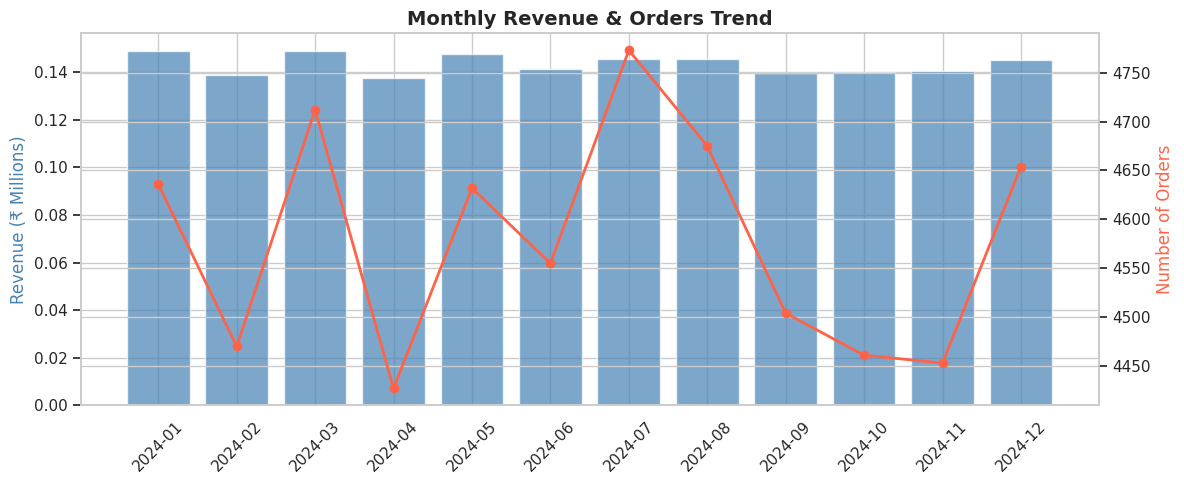

Chart 1 saved!


In [ ]:
fig, ax1 = plt.subplots()

ax1.bar(monthly_rev['month_label'], monthly_rev['revenue'] / 1e6,
        color='steelblue', alpha=0.7, label='Revenue (₹M)')
ax1.set_ylabel('Revenue (₹ Millions)', color='steelblue')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly_rev['month_label'], monthly_rev['orders'],
         color='tomato', marker='o', linewidth=2, label='Orders')
ax2.set_ylabel('Number of Orders', color='tomato')

plt.title('Monthly Revenue & Orders Trend', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig('/content/chart1_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

New Cell D — Chart 2: Revenue by Category

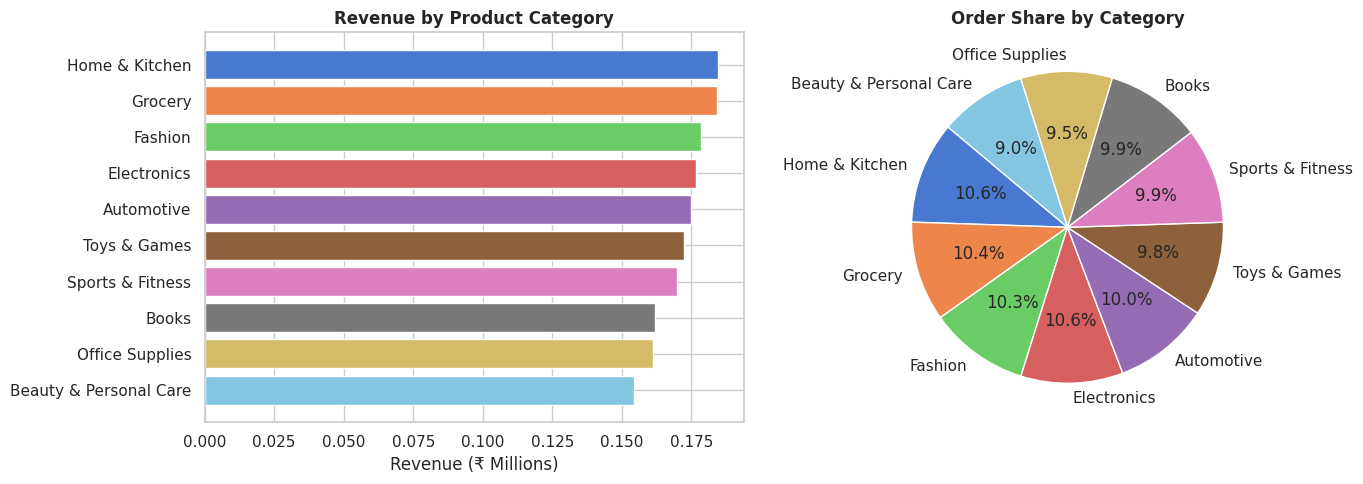

Chart 2 saved!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].barh(category_rev['category'], category_rev['revenue'] / 1e6,
             color=sns.color_palette("muted", len(category_rev)))
axes[0].set_xlabel('Revenue (₹ Millions)')
axes[0].set_title('Revenue by Product Category', fontweight='bold')
axes[0].invert_yaxis()

# Pie chart
axes[1].pie(category_rev['orders'], labels=category_rev['category'],
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette("muted", len(category_rev)))
axes[1].set_title('Order Share by Category', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/chart2_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

New Cell E — Chart 3: City Performance & Payment Methods

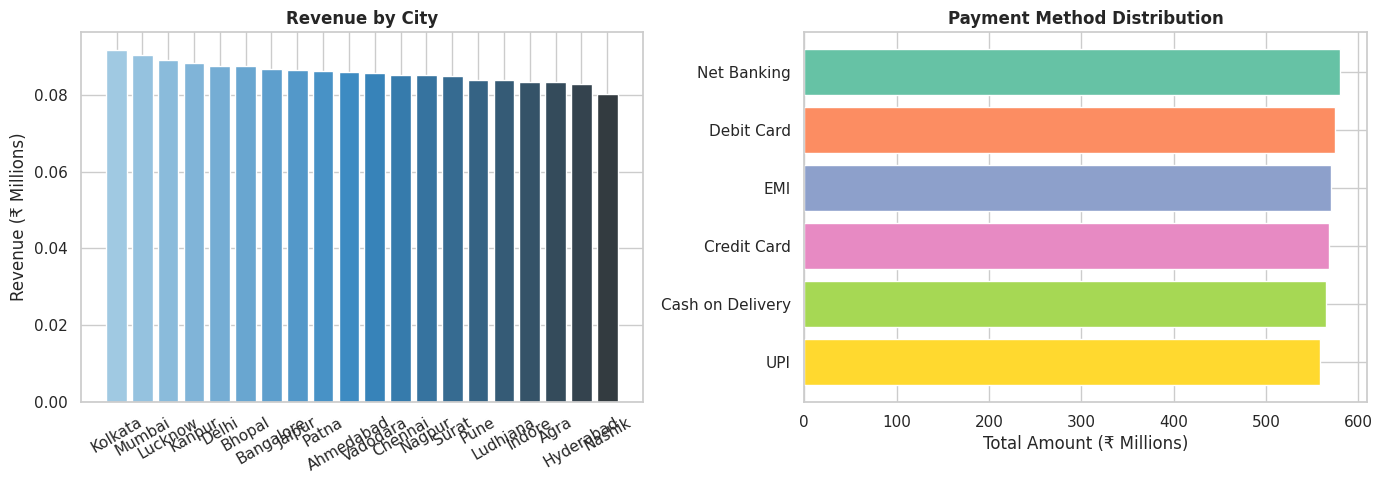

Chart 3 saved!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# City revenue
colors = sns.color_palette("Blues_d", len(city_rev))
axes[0].bar(city_rev['city'], city_rev['revenue'] / 1e6, color=colors)
axes[0].set_ylabel('Revenue (₹ Millions)')
axes[0].set_title('Revenue by City', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# Payment methods
axes[1].barh(payment_data['payment_method'], payment_data['total_amount'] / 1e6,
             color=sns.color_palette("Set2", len(payment_data)))
axes[1].set_xlabel('Total Amount (₹ Millions)')
axes[1].set_title('Payment Method Distribution', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('/content/chart3_city_payment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

New Cell F — Chart 4: Order Status Funnel

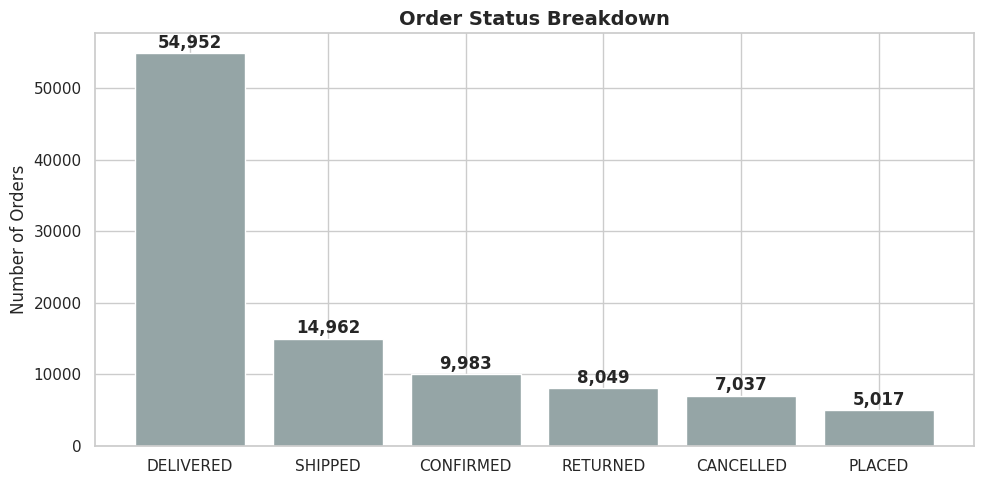

Chart 4 saved!


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = {'delivered': '#2ecc71', 'shipped': '#3498db',
          'confirmed': '#f39c12', 'placed': '#9b59b6', 'cancelled': '#e74c3c'}
bar_colors = [colors.get(s, '#95a5a6') for s in status_data['status']]

bars = ax.bar(status_data['status'], status_data['count'], color=bar_colors)
ax.set_ylabel('Number of Orders')
ax.set_title('Order Status Breakdown', fontsize=14, fontweight='bold')

for bar, val in zip(bars, status_data['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/chart4_order_status.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

New Cell G — Export CSVs for Power BI

In [ ]:
# Export clean aggregated data for Power BI
monthly_rev.to_csv('/content/powerbi_monthly_revenue.csv', index=False)
category_rev.to_csv('/content/powerbi_category_revenue.csv', index=False)
city_rev.to_csv('/content/powerbi_city_performance.csv', index=False)
payment_data.to_csv('/content/powerbi_payments.csv', index=False)
status_data.to_csv('/content/powerbi_order_status.csv', index=False)

# Also export the full customer segments table
segments = conn.execute("SELECT * FROM dim_customer_segments").fetchdf()
segments.to_csv('/content/powerbi_customer_segments.csv', index=False)

print("All CSVs exported for Power BI!")
print("Files:")
for f in ['/content/powerbi_monthly_revenue.csv', '/content/powerbi_category_revenue.csv',
          '/content/powerbi_city_performance.csv', '/content/powerbi_payments.csv',
          '/content/powerbi_order_status.csv', '/content/powerbi_customer_segments.csv']:
    import os
    print(f"  {f} — {os.path.getsize(f):,} bytes")

All CSVs exported for Power BI!
Files:
  /content/powerbi_monthly_revenue.csv — 401 bytes
  /content/powerbi_category_revenue.csv — 293 bytes
  /content/powerbi_city_performance.csv — 432 bytes
  /content/powerbi_payments.csv — 214 bytes
  /content/powerbi_order_status.csv — 99 bytes
  /content/powerbi_customer_segments.csv — 5,102,836 bytes


New Cell H — Download all charts and CSVs

In [ ]:
from google.colab import files

# Download charts
for chart in ['chart1_monthly_revenue.png', 'chart2_category.png',
              'chart3_city_payment.png', 'chart4_order_status.png']:
    files.download(f'/content/{chart}')

# Download Power BI CSVs
for csv in ['powerbi_monthly_revenue.csv', 'powerbi_category_revenue.csv',
            'powerbi_city_performance.csv', 'powerbi_payments.csv',
            'powerbi_order_status.csv', 'powerbi_customer_segments.csv']:
    files.download(f'/content/{csv}')

print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!


Save to Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
os.makedirs('/content/drive/MyDrive/SmartCommerce', exist_ok=True)
shutil.copy('/content/smartcommerce.duckdb', '/content/drive/MyDrive/SmartCommerce/smartcommerce.duckdb')

print("DuckDB database saved to Google Drive")
print("   Path: My Drive/SmartCommerce/smartcommerce.duckdb")
print("\nNext phase: dbt transformations on top of this DuckDB database!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DuckDB database saved to Google Drive
   Path: My Drive/SmartCommerce/smartcommerce.duckdb

Next phase: dbt transformations on top of this DuckDB database!


**dbt**

 Install dbt

In [ ]:
!pip install dbt-duckdb --quiet
!dbt --version
print("dbt installed")

Mount Drive and load DuckDB

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil

# Copy DuckDB from Drive back to Colab
shutil.copy(
    '/content/drive/MyDrive/SmartCommerce/smartcommerce.duckdb',
    '/content/smartcommerce.duckdb'
)
print("DuckDB database loaded from Drive")

Verify your tables are there

In [ ]:
import duckdb
conn = duckdb.connect('/content/smartcommerce.duckdb')
print(conn.execute("SHOW ALL TABLES").fetchdf().to_string(index=False))
conn.close()

Create all project folders

In [ ]:
import os

# Create all folders
folders = [
    '/content/smartcommerce_dbt/models/staging',
    '/content/smartcommerce_dbt/models/marts',
    '/content/smartcommerce_dbt/tests',
    '/content/smartcommerce_dbt/macros',
]
for f in folders:
    os.makedirs(f, exist_ok=True)

print("dbt project folders created")

Create dbt_project.yml

In [ ]:
dbt_project = """
name: 'smartcommerce'
version: '1.0.0'
config-version: 2
profile: 'smartcommerce'

model-paths: ["models"]
test-paths: ["tests"]
macro-paths: ["macros"]

models:
  smartcommerce:
    staging:
      +materialized: view
    marts:
      +materialized: table
"""

with open('/content/smartcommerce_dbt/dbt_project.yml', 'w') as f:
    f.write(dbt_project)

print("dbt_project.yml created")

 Create profiles.yml

In [ ]:
os.makedirs('/root/.dbt', exist_ok=True)

profiles = """
smartcommerce:
  target: dev
  outputs:
    dev:
      type: duckdb
      path: /content/smartcommerce.duckdb
      threads: 4
"""

with open('/root/.dbt/profiles.yml', 'w') as f:
    f.write(profiles)

print("profiles.yml created — dbt connected to DuckDB")

Create sources.yml

In [ ]:
sources_yml = """
version: 2

sources:
  - name: main
    description: "Raw tables loaded from Parquet/CSV into DuckDB"
    tables:
      - name: orders_enriched
        description: "Cleaned and enriched orders from PySpark ETL"
        columns:
          - name: order_id
            tests: [unique, not_null]
          - name: user_id
            tests: [not_null]
          - name: final_amount
            tests: [not_null]

      - name: users
        columns:
          - name: user_id
            tests: [unique, not_null]

      - name: products
        columns:
          - name: product_id
            tests: [unique, not_null]

      - name: payments
        columns:
          - name: payment_id
            tests: [unique, not_null]
"""

with open('/content/smartcommerce_dbt/models/staging/sources.yml', 'w') as f:
    f.write(sources_yml)

print("sources.yml created")

Create stg_orders.sql

In [ ]:
stg_orders = """
WITH source AS (
    SELECT * FROM {{ source('main', 'orders_enriched') }}
),

cleaned AS (
    SELECT
        order_id,
        user_id,
        order_date,
        UPPER(status)                   AS status,
        shipping_city,
        shipping_pincode,
        order_year,
        order_month,
        order_day,
        COALESCE(total_amount, 0)       AS total_amount,
        COALESCE(discount_amount, 0)    AS discount_amount,
        COALESCE(final_amount, 0)       AS final_amount,
        COALESCE(shipping_fee, 0)       AS shipping_fee,
        COALESCE(item_count, 0)         AS item_count,
        COALESCE(total_quantity, 0)     AS total_quantity,
        primary_category,
        is_delivered,
        is_cancelled,
        is_returned,
        is_free_shipping
    FROM source
    WHERE order_id IS NOT NULL
      AND final_amount >= 0
)

SELECT * FROM cleaned
"""

with open('/content/smartcommerce_dbt/models/staging/stg_orders.sql', 'w') as f:
    f.write(stg_orders)

print("stg_orders.sql created")

Create stg_payments.sql

In [ ]:
stg_payments = """
WITH source AS (
    SELECT * FROM {{ source('main', 'payments') }}
)

SELECT
    payment_id,
    order_id,
    user_id,
    CAST(amount AS DOUBLE)              AS amount,
    payment_method,
    payment_gateway,
    UPPER(status)                       AS status,
    payment_date,
    CASE WHEN UPPER(status) = 'SUCCESS'
         THEN TRUE ELSE FALSE END       AS is_successful,
    CASE WHEN UPPER(status) = 'FAILED'
         THEN TRUE ELSE FALSE END       AS is_failed
FROM source
WHERE payment_id IS NOT NULL
"""

with open('/content/smartcommerce_dbt/models/staging/stg_payments.sql', 'w') as f:
    f.write(stg_payments)

print("stg_payments.sql created")

Create fct_daily_revenue.sql

In [ ]:
fct_daily_revenue = """
WITH orders AS (
    SELECT * FROM {{ ref('stg_orders') }}
    WHERE NOT is_cancelled
),

daily AS (
    SELECT
        order_year,
        order_month,
        order_day,
        shipping_city,
        COALESCE(primary_category, 'Unknown')   AS category,

        COUNT(order_id)                         AS total_orders,
        COUNT(DISTINCT user_id)                 AS unique_customers,
        SUM(final_amount)                       AS gross_revenue,
        SUM(discount_amount)                    AS total_discounts,
        SUM(final_amount) - SUM(discount_amount) AS net_revenue,
        AVG(final_amount)                       AS avg_order_value,
        SUM(item_count)                         AS total_items_sold,
        SUM(CASE WHEN is_delivered THEN 1 ELSE 0 END) AS delivered_orders,
        SUM(CASE WHEN is_returned  THEN 1 ELSE 0 END) AS returned_orders,
        SUM(CASE WHEN is_free_shipping THEN 1 ELSE 0 END) AS free_shipping_orders

    FROM orders
    GROUP BY 1, 2, 3, 4, 5
)

SELECT
    *,
    ROUND(returned_orders * 100.0 / NULLIF(delivered_orders, 0), 2) AS return_rate_pct,
    ROUND(free_shipping_orders * 100.0 / NULLIF(total_orders, 0), 2) AS free_shipping_pct,
    CURRENT_TIMESTAMP                                                  AS dbt_updated_at
FROM daily
ORDER BY order_year, order_month, order_day, gross_revenue DESC
"""

with open('/content/smartcommerce_dbt/models/marts/fct_daily_revenue.sql', 'w') as f:
    f.write(fct_daily_revenue)

print("fct_daily_revenue.sql created")

Create dim_customer_segments.sql

In [ ]:
dim_customer_segments = """
WITH delivered_orders AS (
    SELECT * FROM {{ ref('stg_orders') }}
    WHERE is_delivered = TRUE
),

rfm_base AS (
    SELECT
        user_id,
        shipping_city                                               AS city,
        COUNT(DISTINCT order_id)                                    AS order_count,
        SUM(final_amount)                                           AS total_spend,
        AVG(final_amount)                                           AS avg_order_value,
        MIN(CAST(order_date AS DATE))                               AS first_order_date,
        MAX(CAST(order_date AS DATE))                               AS last_order_date,
        CAST(CURRENT_DATE AS DATE) - MAX(CAST(order_date AS DATE))  AS recency_days,
        COUNT(DISTINCT primary_category)                            AS categories_explored
    FROM delivered_orders
    GROUP BY user_id, shipping_city
),

rfm_scored AS (
    SELECT
        *,
        NTILE(5) OVER (ORDER BY recency_days DESC)  AS recency_score,
        NTILE(5) OVER (ORDER BY order_count ASC)    AS frequency_score,
        NTILE(5) OVER (ORDER BY total_spend ASC)    AS monetary_score
    FROM rfm_base
),

segmented AS (
    SELECT
        *,
        recency_score + frequency_score + monetary_score AS rfm_score,
        CASE
            WHEN recency_score >= 4 AND frequency_score >= 4 AND monetary_score >= 4
                THEN 'Champions'
            WHEN recency_score >= 3 AND frequency_score >= 3
                THEN 'Loyal Customers'
            WHEN recency_score >= 4 AND frequency_score <= 2
                THEN 'New Customers'
            WHEN monetary_score >= 4 AND frequency_score <= 2
                THEN 'Big Spenders'
            WHEN recency_score <= 2 AND frequency_score >= 3
                THEN 'At Risk'
            WHEN recency_score <= 2 AND frequency_score <= 2
                THEN 'Lost Customers'
            ELSE 'Potential Loyalists'
        END AS customer_segment
    FROM rfm_scored
)

SELECT * FROM segmented
ORDER BY rfm_score DESC
"""

with open('/content/smartcommerce_dbt/models/marts/dim_customer_segments.sql', 'w') as f:
    f.write(dim_customer_segments)
print("dim_customer_segments.sql fixed")

Run dbt (all models)

In [ ]:
# This runs all models in order: sources → staging → marts
os.chdir('/content/smartcommerce_dbt')
!dbt run --profiles-dir /root/.dbt

Run dbt tests

In [ ]:
# dbt tests validate your data automatically
# not_null, unique, accepted_values — these run every pipeline execution
!dbt test --profiles-dir /root/.dbt

In [ ]:
import duckdb

# Delete the conflicting Python variables from memory
for var in ['dim_customer_segments', 'stg_orders', 'stg_payments', 'fct_daily_revenue']:
    if var in dir():
        del var

# Open a fresh connection
con = duckdb.connect('/content/smartcommerce.duckdb')

# Check what tables exist first
print("--- All tables in DuckDB ---")
print(con.execute("SHOW ALL TABLES").fetchdf()[['schema', 'name']].to_string(index=False))

Final queries

In [ ]:
# Clear ALL variables in the session
%reset -f
print("Session cleared")

In [ ]:
import duckdb
conn = duckdb.connect('/content/smartcommerce.duckdb')

print("=== Customer Segments ===")
print(conn.execute("""
    SELECT customer_segment,
           COUNT(*)                   AS customers,
           ROUND(AVG(total_spend), 0) AS avg_spend,
           ROUND(AVG(order_count), 1) AS avg_orders
    FROM   main.dim_customer_segments
    GROUP  BY customer_segment
    ORDER  BY avg_spend DESC
""").fetchdf().to_string(index=False))

print("\n=== Top 5 Revenue Days ===")
print(conn.execute("""
    SELECT order_year, order_month, order_day,
           ROUND(SUM(gross_revenue), 0) AS revenue,
           SUM(total_orders)            AS orders
    FROM   main.fct_daily_revenue
    GROUP  BY 1, 2, 3
    ORDER  BY revenue DESC
    LIMIT  5
""").fetchdf().to_string(index=False))

print("\n=== Payment Method Performance ===")
print(conn.execute("""
    SELECT payment_method,
           COUNT(*)                                         AS transactions,
           SUM(CASE WHEN is_successful THEN 1 ELSE 0 END)  AS successful,
           SUM(CASE WHEN is_failed     THEN 1 ELSE 0 END)  AS failed
    FROM   main.stg_payments
    GROUP  BY payment_method
    ORDER  BY transactions DESC
""").fetchdf().to_string(index=False))

 Save everything to Drive

In [ ]:
from google.colab import drive
import shutil

conn.close()
drive.mount('/content/drive')
shutil.copy('/content/smartcommerce.duckdb',
            '/content/drive/MyDrive/SmartCommerce/smartcommerce.duckdb')
print("Saved to Drive — Phase 4 complete!")